In [47]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
import yaml
import time
import pickle as pkl
import os
import sys
import numpy as np
from matplotlib import cm
from scipy import signal
from scipy.signal import butter, welch, filtfilt, periodogram, savgol_filter
import pandas as pd
import glob
from scipy.optimize import curve_fit
from scipy.optimize import fminbound
import scipy.linalg as linalg
import scipy as sp
# sys.path.append("/home/cryo/.local/lib/python3.10/site-packages/")
# import nbimporter

plt.ion()
%matplotlib inline

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE, family='serif')          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE, facecolor='white') 

# Import useful functions

In [48]:
# Import useful wrapper functions

sys.path.append("/home/cryo/docker/pysmurf/dev/v8.0.0-rc3_rfsoc/pysmurf/scratch/adroster")
from utils import *

# Define useful functions

In [93]:
def welch_IQ(iq, fs,  plot=True, welch_nperseg=2**18, title='', show_plot=True):
    i = iq.real
    q = iq.imag
    ffi, pxxi = welch(i,fs=fs, nperseg=welch_nperseg)
    ffq, pxxq = welch(q,fs=fs, nperseg=welch_nperseg)

    # scale to dBc/Hz by the voltage magnitude
    magfac = np.mean(q)**2 + np.mean(i)**2
    pxxi_dbc = 10. * np.log10(pxxi / magfac)
    pxxq_dbc = 10. * np.log10(pxxq / magfac)


    if plot:
        plt.gca().semilogx(ffi,pxxi_dbc,linestyle='-',label=f'i {title}')
        plt.gca().semilogx(ffq,pxxq_dbc, linestyle='--',label=f'q {title}')
        plt.ylabel('dBc/Hz')
        plt.xlabel('Frequency (Hz)')
        plt.title(title)
        plt.legend(loc='lower left')
        if show_plot: plt.show()
    return

def freqSweep(S, band, start_freq=-250, stop_freq=250, subband=None, tone_power=None, n_avg=1, makeplot=False):
    """
    Inputs:
    S (obj): PySMuRF control instance
    start_freq (int): start frequency of sweep in the IF [MHz]
    stop_freq (int): stop frequency of sweep in the IF [MHz]
    subband:
    tone_power (int): int between 0 and 15. Each integer is 0.5 dBm of power. Not much dynamic range here. Defaults to 12 due to config file.
    n_avg (int): nubmer of times to average. this is a sweep-to-sweep average, analogous to averaging on a VNA
    makeplot (bool): 

    Outputs:
    freqs (ndarray): real-valued 1D array of frequenies (RF, not IF)
    resp_avg (ndarray): complex-valued 1D array of response

    Note on using either sideband of the mixer:
    Certain - signs need to be flipped to + signs when using the RHS of the mixer. As written, this is for a LO tuned to 750 MHz above\
    the the desired center frequency. See comments on which signs to flip.
    """
    #adapted from S.find_freq()
    band_center = S.get_band_center_mhz(band)
    if subband is None:
        #flip these two minuses to plusses whn using RHS of mixer
        start_subband = S.freq_to_subband(band, band_center - start_freq)[0]
        stop_subband = S.freq_to_subband(band, band_center - stop_freq)[0]
        step = 1
        if stop_subband < start_subband:
            step = -1
        subband = np.arange(start_subband, stop_subband+1, step)
        #print(subband)
    else:
        sb, sbc = S.get_subband_centers(band)
        start_freq = sbc[subband[0]]
        stop_freq  = sbc[subband[-1]]

    # Turn off all tones in this band first.  May want to make
    # this only turn off tones in each sub-band before sweeping,
    # instead?
    S.band_off(band)

    if tone_power is None:
        tone_power = S._amplitude_scale[band]
        S.log('No tone_power given. Using value in config ' +
                 f'file: {tone_power}')

    #the following for loop does an amplitude sweep n_avg times, reads the response, and addes the response array to resp_tot
    #resp_tot has shape (n_avg, 31*n_channels). n_channels is the number of processed channels + 1; there are 31 frequencies per channel.
    S.log(f'Sweeping across frequencies {start_freq + band_center}MHz to {stop_freq + band_center}MHz. Averaging {n_avg} traces.')
    BW_MHz = 500
    freqs_per_channel = 31
    n_channels = int(np.ceil((S.get_number_processed_channels(band))*(stop_freq - start_freq)/BW_MHz)+1)
    resp_shape = (n_avg, freqs_per_channel*n_channels)
    #resp_arr = np.zeros(resp_shape, dtype = np.complex_)
    resp_arr = []
    for n in range(n_avg):
        f, resp = S.full_band_ampl_sweep(band, subband, tone_power, n_read=2) #n_read doesn't actually do anything; must be legacy code from previous SMuRF implementations
        
        # below is adapted from S.find_all_peak()
        # Stack all the frequency and response data into a
        # Frequency array is the same on every iteration, so only need to find & sort frequencies once
        if n == 0:
            sb, _ = np.where(f !=0)
            idx = np.unique(sb)
            f_stack = np.ravel(f[idx])
            # Frequency is interleaved, so sort it
            s = np.argsort(f_stack)
            f_stack = f_stack[s]
            freqs = f_stack
            print(freqs)

            # convert frequencies from IF to the RF
            if band is not None:
                bandCenterMHz = S.get_band_center_mhz(band)
                scale = 1
                if np.max(f_stack) > 1.0E8:
                    self.log('Frequency is probably in Hz. Converting to MHz')
                    scale = 1.0E-6
                #flip these two minus signs to + signs when using RHS of mixer
                freq_rf = bandCenterMHz - freqs*scale
            else:
                freq_rf = bandCenterMHz - freqs
            
        r_stack = np.ravel(resp[idx])
    
        # response is also interleaved, so sort it
        r_stack = r_stack[s]
        #r_stack = r_stack[::-1]

        #append the sorted & stacked response array to resp_arr
        #resp_arr[n,:] = r_stack
        resp_arr.append(r_stack)

    #Frequencies are just f_stack; Average the response

    resp_arr = np.array(resp_arr)
    resp_avg = np.mean(resp_arr, axis=0)
    
    # Break apart the data to find phase, deriv of phase
    angle = np.unwrap(np.angle(resp_avg))
    x = np.arange(len(angle))
    p1 = np.poly1d(np.polyfit(x, angle, 1))
    angle -= p1(x)
    grad_kernel_width = 8
    grad = np.convolve(angle, np.repeat([1,-1], grad_kernel_width), mode='same')
    #grad_kernel_width is number of samples to take after a point to calculate gradient; default is 8

    #find the amplitude
    amp = np.abs(resp_avg)
    
    #calculating rolling median. Adapted from S.find_peaks()   
    # Calculate the rolling median. This uses pandas. This is analogous to smoothing on a VNA.
    import pandas as pd
    med_amp = pd.Series(amp).rolling(window=50, center=True, min_periods=1).median() 
    
    #plotting
    if makeplot:
        plt.ion()

        fig, ax = plt.subplots(2, figsize=(8,6), sharex=True)

        # Plot response
        ax[0].plot(freq_rf, amp)
        ax[0].plot(freq_rf, med_amp)

        ax[1].plot(freq_rf, grad)
        ax[1].set_ylim(-2, 20)

        ax[0].set_ylabel('Amp.')
        ax[1].set_ylabel('Deriv Phase')
        ax[1].set_xlabel('Freq. [MHz]')

        # Text label
        text = ''
        if band is not None:
            text += f'Band: {band}' + '\n'
            text += f'Center Freq: {bandCenterMHz} MHz' + '\n'
        ax[0].text(.025, .975, text, transform=ax[0].transAxes, ha='left',
            va='top')

    
    return freq_rf, resp_avg

# find the frequency between parity bands
def lorentzian(f, f0, Gc, Gr, g, Omega, slope):
    Delta = 2*np.pi*(f - f0)
    S21 = 1 - (Gc/2/g)*(1-Delta*1j/g)/(1+(Delta/g)**2+(2*np.pi*Omega)**2/g/Gr) + slope*Delta
    return S21
    
def invertedDoubleLorentzian(f, f0_1, f0_2, Gc_1, GC_2, Gr_1, Gr_2, g_1, g_2, Omega_1, Omega_2, baseline, scale, slope):
    '''
    Eq. E22 in the design paper
    '''
    lorentzian1 = lorentzian(f, f0_1, Gc_1, Gr_1, g_1, Omega_1, slope)
    lorentzian2 = lorentzian(f, f0_2, Gc_2, Gr_2, g_2, Omega_2, slope)
    S21 = baseline + scale*(lorentzian1 + lorentzian2)
    return np.abs(S21)

def negInvertedDoubleLorentzian(f, f0_1, f0_2, Gc_1, GC_2, Gr_1, Gr_2, g_1, g_2, Omega_1, Omega_2, baseline, scale, slope):
    '''
    Eq. E22 in the design paper
    '''
    return -invertedDoubleLorentzian(f, f0_1, f0_2, Gc_1, GC_2, Gr_1, Gr_2, g_1, g_2, Omega_1, Omega_2, baseline, scale, slope)

def takeDebugData(S, band, channel, nsamp, plot=True, welch_nperseg=2**18, show_plot=True, channel_mode=0):
    timestamp = S.get_timestamp()
    filename = f'{timestamp}_multi_channel_b{band}'
    if channel is not None:
        filename = f'{timestamp}_single_channel_b{band}ch{channel:03}'
    i,q,sync = S.take_debug_data(band=band,channel=channel,rf_iq=True,nsamp=nsamp,filename=filename, single_channel_readout=channel_mode) 
    i = i / (1.2)
    q = q / (-1.2)
    iq = i + 1j * q
    if plot: 
        fs = S.get_channel_frequency_mhz(band) * 1.0E6
        welch_IQ(iq, fs, welch_nperseg, title=filename, show_plot=show_plot)
        ### save plots 
        fig = plt.gcf()
        #plt.savefig(f'/data/smurf_data/mkid_1tone_streaming_metadata/_Figs/{filename}_psd', fmt='tiff')
        plt.show()
    return iq, sync, filename

def butterworth_filter(data, fs, cutoff_hz=200, order=1):
    b, a = butter(N=order, Wn=cutoff_hz, btype='low', fs=fs)
    zi = sp.signal.lfilter_zi(b, a)
    filt_data, _ = sp.signal.lfilter(b, a, data, zi=zi*data[0])
    return filt_data

# Initialize a pysmurf control instance

In [50]:
import pysmurf.client
import epics
import os
import time

%matplotlib inline

epics_prefix="smurf_server_s3"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

## Dump versions of everything
# Python version
print(sys.version)
import pysmurf
pysmurf.__version__
cwd=os.getcwd()
os.chdir('/usr/local/src/pysmurf/')
#print(str(!git branch))
#print(!git rev-parse --short HEAD)
print(S.get_fpga_git_hash_short())
print(S.config.filename)

[ 2026-04-06 21:31:13 ]  ERROR : band 0 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-06 21:31:13 ]  ERROR : band 1 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-06 21:31:13 ]  ERROR : band 2 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-06 21:31:13 ]  ERROR : band 3 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-06 21:31:13 ]  ERROR : band 4 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-06 21:31:13 ]  ERROR : band 5 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-06 21:31:13 ]  ERROR : band 6 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-04-06 21:31:13 ]  ERROR : band 7 is present in pysmurf cfg file, but its bay is not enabled!
3.8.10 (default, Mar 13 2023, 10:26:41) 
[GCC 9.4.0]
9355e2a
/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg


In [ ]:
S.log('starting')

## Define the LO frequency

In [51]:
LO_freq_MHz = 6700+750

## Set SMuRF parameters

In [7]:
S.log_file

AttributeError: 'SmurfControl' object has no attribute 'log_file'

In [7]:
S.all_off()

[ 2026-03-25 21:23:12 ]  Turning off tones
[ 2026-03-25 21:23:31 ]  Turning off flux ramp
[ 2026-03-25 21:23:31 ]  Turning off all TES biases


In [52]:
S.get_band_center_mhz(band=0)

4250.0

The baseband center of 4250 MHz is a legacy number from old smurf versions. The RFSoC board has a baseband center of 750 MHz. But the LO mixes this up to 8.5 GHz (9250-750=8500.) Let's tell the software what's what:

In [53]:
S.set_band_center_mhz(0,LO_freq_MHz-750)

In [54]:
S.get_band_center_mhz(band=0)

6700.0

In [55]:
# amp_readout_freq = center_parity_bands_MHz
#S.all_off()
center_parity_bands_MHz = 6700
S.set_band_center_mhz(0, LO_freq_MHz-750)
amp_readout_freq = 750 + np.abs(S.get_band_center_mhz(0)-center_parity_bands_MHz)
my_log = f'Sending fixed tone at {amp_readout_freq} MHz'

print(f'amp readout freq = {amp_readout_freq}')

S.set_band_center_mhz(0, 750)
(band,channel)=S.set_fixed_tone(amp_readout_freq,12)
S.set_band_center_mhz(0, LO_freq_MHz-750)

amp readout freq = 750.0


In [56]:
S.get_band_center_mhz(band=0)

6700.0

In [57]:
S.which_on(0)

array([], dtype=int64)

# Thru fridge
Use SMuRF to do a VNA-like sweep of the frequency band; save the frequency and response arrays.

[ 2026-04-07 00:04:48 ]  No tone_power given. Using value in config file: 12
[ 2026-04-07 00:04:48 ]  Sweeping across frequencies 6550.0MHz to 6750.0MHz
[ 2026-04-07 00:04:48 ]  Working on band 0
[ 2026-04-07 00:05:07 ]  serial find freq complete ; etaScanInProgress = 0


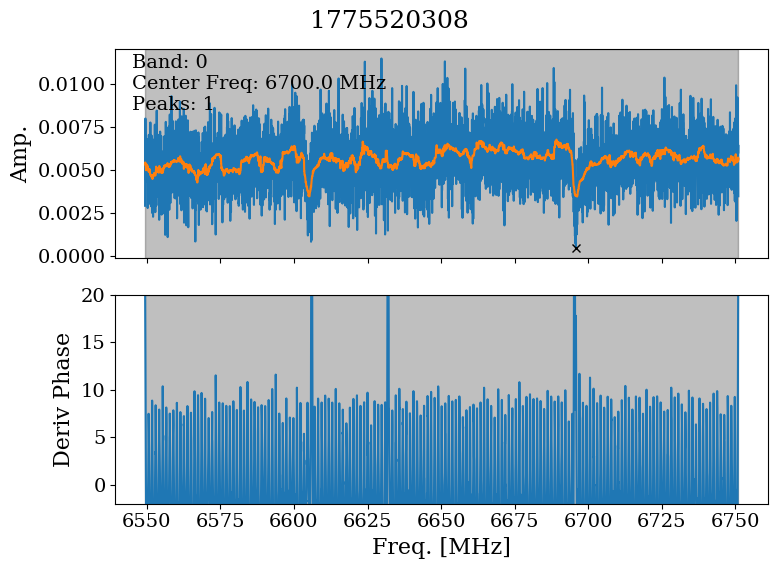

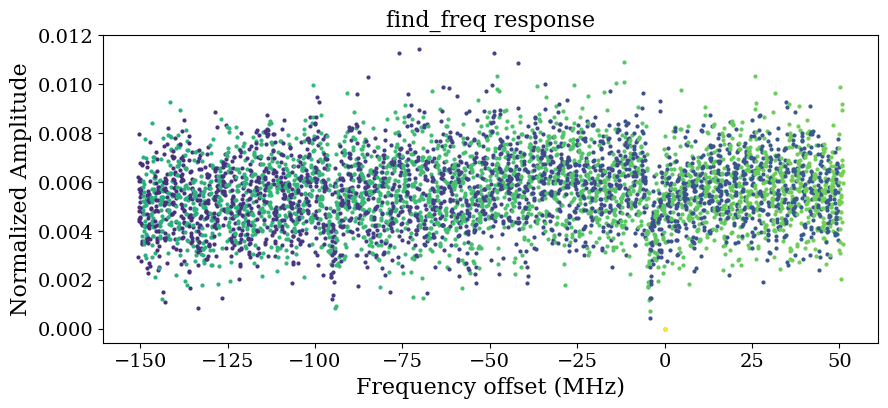

In [88]:
f, resp = S.find_freq(band=0, start_freq = -150, stop_freq = 50, make_plot=True, show_plot=True, grad_cut =.5,\
                      amp_cut = .8, pad = 12, min_gap = 20)

[ 2026-04-07 00:18:53 ]  No tone_power given. Using value in config file: 12
[ 2026-04-07 00:18:53 ]  Sweeping across frequencies 6650.0MHz to 6850.0MHz. Averaging 1 traces.
[ 2026-04-07 00:18:53 ]  Working on band 0
[ 2026-04-07 00:19:10 ]  serial find freq complete ; etaScanInProgress = 0
[-148.2  -148.16 -148.12 ...   50.92   50.96   51.  ]


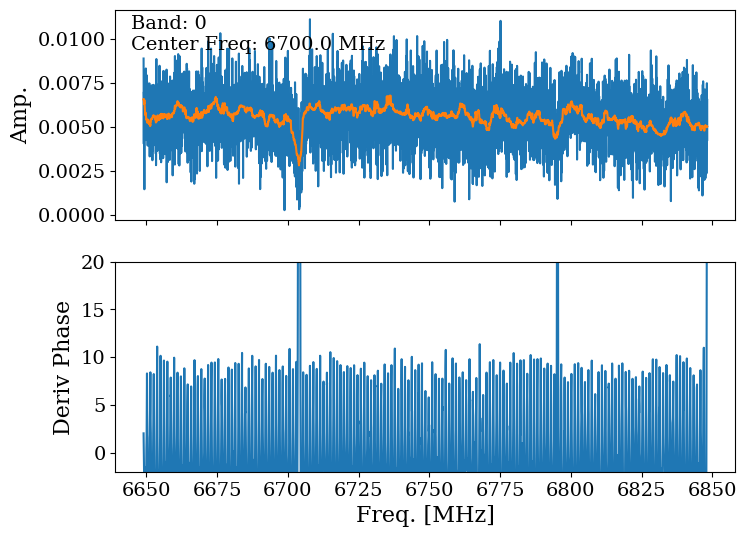

In [94]:
f2, resp2 = freqSweep(S, band=0, start_freq=-50, stop_freq=150, subband=None, tone_power=None, n_avg = 1
                      , makeplot=True)

# Look for the qubits

From VNA scans, H2 qubits should be located at:
* H2Q1 = 8365.5 MHz
* H2Q2 = 8418.1 MHz
* H2Q3 = 8470.5 MHz

In [11]:
f_qubit1 = 8365.5
f_qubit2 = 8418.1
f_qubit3 = 8470.5

### H2Q1

In [12]:
relative_start = -110
relative_stop = -80

LO_freq = 9150
LO_power = 10

smurf_start = LO_freq - (750+relative_start)
smurf_stop = LO_freq - (750+relative_stop)
print(f"\nSMuRF start: {smurf_start} MHz")
print(f"SMuRF stop: {smurf_stop} MHz")
S.log('SMURF range is from {} to {} MHz'.format(smurf_start,smurf_stop))


SMuRF start: 8510 MHz
SMuRF stop: 8480 MHz
[ 2026-03-05 22:39:15 ]  SMURF range is from 8510 to 8480 MHz


In [ ]:
## now average the spectrum several times to improve SNR near the qubit
n_avg = 10

f3, resp3 = freqSweep(S, band=0, start_freq=-10, stop_freq=20, subband=None, tone_power=None, n_avg = n_avg, makeplot=False)

amp = np.abs(resp3)
phase = np.angle(resp3)

## Find the center of the parity bands, readout at that frequency
We fit a double Lorentzian to the parity bands using Eq. 22 from the characterization paper. Then we minimize (the negative of) this fit function to find the center of the parity bands.

In [13]:
# initial guess
center_parity_bands_MHz = 8391.5

f0_1 = f_qubit2
Gc_1 = 10 # MHz
Gr_1 = 10 # Mhz
g_1 = 5 # MHz
Omega_1 = 1 # MHz
f0_2 = f_qubit2+2.5
Gc_2 = 6 # MHz
Gr_2 = 6 # Mhz
g_2 = 3 # MHz
Omega_2 = 1 # MHz
scale = .001
baseline = 0.02

# Fit to fit function
p0 = (f0_1, f0_2, Gc_1, Gc_2, Gr_1, Gr_2, g_1, g_2, Omega_1, Omega_2, scale, baseline)
bounds = ((8300, 8300, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0),(8600,8600,20,20,20,20,20,20,20,20,1,1))
#popt, pcov = curve_fit(invertedDoubleLorentzian, f3, amp, p0 = p0, bounds = bounds)

# find the center of the parity bands
f0_1 = p0[0]
f0_2 = p0[1]
#center_parity_bands_MHz = fminbound(negInvertedDoubleLorentzian, f0_1, f0_2, popt)
f0_1 = center_parity_bands_MHz - .5
f0_2 = center_parity_bands_MHz + .5

In [ ]:
## plot the results
plt.figure(figsize=(7,8))
plt.subplot(2,1,1)
plt.plot(f3, amp)
#plt.plot(f3, invertedDoubleLorentzian(f3, *popt), 'r-', label = 'fit')
plt.axvline(x=f0_1, color='r', linestyle='--', label=f'{f0_1} MHz')
plt.axvline(x=f0_2, color='r', linestyle='--', label=f'{f0_2} MHz')
plt.axvline(x=center_parity_bands_MHz, color='g', linestyle='--', label=f'{center_parity_bands_MHz} MHz')
#plt.axis([8360,8380,-.0001,.0003])
plt.title('Magnitude')
plt.legend()
plt.subplot(2,1,2)
plt.plot(f3, phase)
plt.title('Phase')
plt.suptitle(f'H2Q1, frequency scan with {n_avg} averages')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

### Send a tone at the center of the parity bands

Recall that SMuRF only outputs tones between 500 - 1000 MHz which then get mixed up to the GHz. Therefore, the center of the parity bands in the IF is  $c_{pb}^{IF} = 750 + |f_{center}^{RF} - c_{pb}^{RF}|$, where $f_{center}^{RF}$ is the band center in the RF, typically LO - 750 MHz, and $c_{pb}^{RF}$ is the center of th parity bands in the RF.

We also need to tell SMuRF that the band center is 750 MHz. pySMuRF will throw an error if you try to place a tone more than 500 MHz from the band center.

In [ ]:
S.get_channel_frequency_mhz(0)

In [ ]:
print(channel)

In [ ]:
print(center_parity_bands_MHz)

In [ ]:
S.all_off()
# amp_readout_freq = center_parity_bands_MHz
S.set_band_center_mhz(0, LO_freq_MHz-750)
amp_readout_freq = 750 + np.abs(S.get_band_center_mhz(0)-center_parity_bands_MHz)
my_log = f'Sending fixed tone at {amp_readout_freq} MHz'
print(my_log)
S.log(my_log)

S.set_band_center_mhz(0, 750)
(band,channel)=S.set_fixed_tone(amp_readout_freq,12)

#S.run_serial_eta_scan(0)

## Read I & Q at the center of the parity bands
At frequency = channel, use takeDebugData() to read I & Q. Then FFT the results (using the Welch method to smooth the psd). We can plot the psd of I, Q, or the amplitude and phase of I+iQ. Most of the signal will be in the phase.

In [ ]:
iq, sync, filename = takeDebugData(S, band=band, channel=channel, nsamp=2**25, 
                                   plot=True, show_plot=True, channel_mode=2)

## Plot amp, phase of IQ

In [ ]:
fs = S.get_channel_frequency_mhz(band) * 1.0E6

ffamp, pxxa = welch(np.abs(iq),fs=fs, nperseg=2**18)
ffphase, pxxph = welch(np.angle(iq),fs=fs, nperseg=2**18)

timestamp = S.get_timestamp() 
filename = f'{timestamp}_single_channel_b{band}ch{channel:03}'
plt.gca().loglog(ffphase,pxxph, linestyle='--',label=f'phase {filename}')
plt.ylabel('phase psd')
plt.xlabel('Frequency (Hz)')
plt.title('phase_'+filename)
plt.show()

plt.gca().loglog(ffamp,pxxa,linestyle='-',label=f'amp {filename}')
plt.ylabel('amp psd')
plt.xlabel('Frequency (Hz)')
plt.title('amplitude_'+filename)


In [ ]:
# fit to Lorentzian
# initial guess
S0_guess = np.max(pxxph)
F_guess = .3
peak_freq_guess = ffphase[np.argmax(pxxph)]
p0 = (2e-1, F_guess, 50, 1e-5)
#mid_indx = int(len(ffphase)//100)
#sigmas = np.ones(mid_indx)
#sigmas[:int(mid_indx/10)] = .4
#popt, pcov = curve_fit(corrected_lorentzian_psd, ffphase, pxxph, p0 = p0)

print(p0)
print(popt)

plt.gca().loglog(ffphase,pxxph, linestyle='--')
#plt.gca().loglog(ffphase, corrected_lorentzian_psd(ffphase, *popt), 'r-', label = 'fit, $\Gamma_p$={:d}'.format(int(popt[2])))
plt.ylabel('phase psd')
plt.xlabel('Frequency (Hz)')
plt.title('phase_'+filename)
plt.legend()
plt.show()

### Use a Butterworth lowpass filter with cutoff freq = 500 Hz to smooth the time domain signal; plot the results

In [ ]:
fs = S.get_channel_frequency_mhz(band) * 1.0E6

cutoff_hz = 500
order = 2

butter_ivals = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq), fs=fs)
butter_qvals = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq), fs=fs)

In [ ]:
start_plot_time_s = 0.1
stop_plot_time_s = 1

## Find indices that best match times
times = np.arange(len(iq)) / fs
start_plot_idx = np.argmin(np.abs(times - start_plot_time_s))
stop_plot_idx = np.argmin(np.abs(times - stop_plot_time_s))

fig, ax = plt.subplots(4,1, figsize=(12,15), sharex=True)
ax[0].plot(times[start_plot_idx:stop_plot_idx], butter_ivals[start_plot_idx:stop_plot_idx], '.',label='I', markersize=0.4)
ax[0].set_ylabel(['Ivals'])

ax[1].plot(times[start_plot_idx:stop_plot_idx], butter_qvals[start_plot_idx:stop_plot_idx],'.', label='Q', markersize=0.4)
ax[1].set_ylabel(['Qvals'])

ax[2].plot(times[start_plot_idx:stop_plot_idx], np.abs(butter_ivals+1j*butter_qvals)[start_plot_idx:stop_plot_idx], '.', label='amp', markersize=0.4)
ax[2].set_ylabel(['amp'])

ax[3].plot(times[start_plot_idx:stop_plot_idx], np.unwrap(np.angle(butter_ivals+1j*butter_qvals)[start_plot_idx:stop_plot_idx]), '.', label='phase', markersize=0.4)
ax[3].set_ylabel(['phase'])
ax[3].set_xlabel('Time [s]')

fig.suptitle(f'{filename} filtered to {cutoff_hz} Hz')

plt.show()

## Set a tone on both parity bands, plot I and Q for both bands
Generally the bands (in SMuRF; not parity bands) are the same (band 0) but the channel is different for each parity band.

In [ ]:
S.all_off()

In [ ]:
S.which_on(0)

In [ ]:
print("bands:", band)
print("channel:", channel)
print("which_bands:", S.which_bands())
print("which_on(band):", S.which_on(band))
print("diff:", np.diff(S.which_on(band)))
subband, foff = S.freq_to_subband(band, S.get_band_center_mhz(0))
print("subband:", subband)
subband_channels = S.get_channels_in_subband(band, subband)
print("subband_channels:", subband_channels)
print("get num processed channels:", S.get_number_processed_channels(band))
print("\n")

In [ ]:
S.all_off()

In [ ]:
band_center_RF = LO_freq_MHz - 750
amp_readout_freq_1 = 750 + np.abs(band_center_RF - (f0_1-1))
amp_readout_freq_2 = 750 + np.abs(band_center_RF - (f0_1+1))
my_log = f'Sending fixed tone at {amp_readout_freq_1} MHz and {amp_readout_freq_2} MHz'
print(my_log)
S.log(my_log)

S.set_band_center_mhz(0, 750)
(band_1,channel_1)=S.set_fixed_tone(amp_readout_freq_1,12)
(band_2,channel_2)=S.set_fixed_tone(amp_readout_freq_2,12)

In [ ]:
S.which_on(0)

In [ ]:
S.get_channel_frequency_mhz(0)

In [ ]:
iq_1, sync_1, filename_1 = takeDebugData(S, band=band_1, channel=channel_1, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=2)

iq_2, sync_2, filename_2 = takeDebugData(S, band=band_2, channel=channel_2, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=2)

fs_1 = S.get_channel_frequency_mhz(band_1) * 1.0E6
fs_2 = S.get_channel_frequency_mhz(band_2) * 1.0E6

In [ ]:
cutoff_hz = 2000
order = 2

butter_ivals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_1), fs=fs_1)
butter_qvals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_1), fs=fs_1)

butter_ivals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_2), fs=fs_2)
butter_qvals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_2), fs=fs_2)

In [ ]:
plt.scatter(butter_ivals_1[::100], butter_qvals_1[::100], s = 1)
plt.scatter(butter_ivals_2[::100], butter_qvals_2[::100], s = 1)
#plt.axis([-.0004,.0004,-.0004,.0004])
plt.tick_params(axis='x', labelrotation=35) # Rotate x-axis labels by 45 degrees
plt.tight_layout()
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ filtered, both parity bands, pwr=2')

In [ ]:
plt.scatter(np.real(iq_1)[::100], np.imag(iq_1)[::100], s = 1)
plt.scatter(np.real(iq_2)[::100], np.imag(iq_2)[::100], s = 1)
plt.axis([-.004,.004,-.004,.004])
plt.tick_params(axis='x', labelrotation=35) # Rotate x-axis labels by 45 degrees
plt.tight_layout()
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ, both parity bands, pwr=2')

Notice the weird data points that look like trails or tails to the IQ blobs. What timescale are these points?

In [ ]:
indx_slicer = 3500
plt.scatter(butter_ivals_1[:indx_slicer], butter_qvals_1[:indx_slicer], s = 1)
plt.scatter(butter_ivals_2[:indx_slicer], butter_qvals_2[:indx_slicer], s = 1)
#plt.axis([-.0004,.0004,-.0004,.0004])
plt.tick_params(axis='x', labelrotation=35) # Rotate x-axis labels by 45 degrees
plt.tight_layout()
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ, both parity bands; first {} data points'.format(indx_slicer))

Timescale of those weird dots (seconds):

In [ ]:
3000 / (S.get_channel_frequency_mhz(0) * 1e6)

In [ ]:
S.which_on(0)

Total time of acquisition (seconds):

In [ ]:
len(iq_2)/(S.get_channel_frequency_mhz(0) * 1e6)

In [ ]:
sync_1.shape

In [ ]:
S.get_number_processed_channels(0)

In [ ]:
S.get_number_sub_bands(0)

In [ ]:
2**25

### Playing around with channel mode and setting channel to None

I have no idea what channel_mode does, and epics documentation has nothing on it. I'd also like to know what happens with setting channel = None. Let's take debug data in each case and compare.

channel_mode = 1

In [ ]:
iq_1, sync_1, filename_1 = takeDebugData(S, band=band_1, channel=channel_1, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=1)

iq_2, sync_2, filename_2 = takeDebugData(S, band=band_2, channel=channel_2, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=1)

fs_1 = S.get_channel_frequency_mhz(band_1) * 1.0E6
fs_2 = S.get_channel_frequency_mhz(band_2) * 1.0E6

cutoff_hz = 500
order = 2

butter_ivals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_1), fs=fs_1)
butter_qvals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_1), fs=fs_1)

butter_ivals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_2), fs=fs_2)
butter_qvals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_2), fs=fs_2)

In [ ]:
S.get_channel_frequency_mhz(0)

In [ ]:
iq_2.shape

In [ ]:
plt.scatter(butter_ivals_1[::100], butter_qvals_1[::100], s = 1)
plt.scatter(butter_ivals_2[::100], butter_qvals_2[::100], s = 1)
plt.axis([-.0004,.0004,-.0004,.0004])
plt.tick_params(axis='x', labelrotation=35) # Rotate x-axis labels by 45 degrees
plt.tight_layout()
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ, both parity bands')

channel_mode = 0

In [ ]:
iq_1, sync_1, filename_1 = takeDebugData(S, band=band_1, channel=channel_1, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=0)

iq_2, sync_2, filename_2 = takeDebugData(S, band=band_2, channel=channel_2, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=0)

fs_1 = S.get_channel_frequency_mhz(band_1) * 1.0E6
fs_2 = S.get_channel_frequency_mhz(band_2) * 1.0E6

cutoff_hz = 500
order = 2

butter_ivals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_1), fs=fs_1)
butter_qvals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_1), fs=fs_1)

butter_ivals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_2), fs=fs_2)
butter_qvals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_2), fs=fs_2)

In [ ]:
iq_2.shape

In [ ]:
S.which_on(0)

In [ ]:
plt.scatter(butter_ivals_1[::100], butter_qvals_1[::100], s = 1)
plt.scatter(butter_ivals_2[::100], butter_qvals_2[::100], s = 1)
plt.axis([-.0004,.0004,-.0004,.0004])
plt.tick_params(axis='x', labelrotation=35) # Rotate x-axis labels by 45 degrees
plt.tight_layout()
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ, both parity bands')

Like in Shawn's multitone code, let's do channel = None and channel_mode = 1

In [ ]:
iq_1, _, filename_1 = takeDebugData(S, band=band_1, channel=None, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=1)

iq_2, _, filename_2 = takeDebugData(S, band=band_2, channel=None, nsamp=2**25, 
                                   plot=False, show_plot=False, channel_mode=1)

fs_1 = S.get_channel_frequency_mhz(band_1) * 1.0E6
fs_2 = S.get_channel_frequency_mhz(band_2) * 1.0E6

cutoff_hz = 500
order = 2

butter_ivals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_1), fs=fs_1)
butter_qvals_1 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_1), fs=fs_1)

butter_ivals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq_2), fs=fs_2)
butter_qvals_2 = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq_2), fs=fs_2)

In [ ]:
iq_2.shape

In [ ]:
plt.scatter(butter_ivals_1[::100], butter_qvals_1[::100], s = 1)
plt.scatter(butter_ivals_2[::100], butter_qvals_2[::100], s = 1)
#plt.axis([-.0004,.0004,-.0004,.0004])
plt.tick_params(axis='x', labelrotation=35) # Rotate x-axis labels by 45 degrees
plt.tight_layout()
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ, both parity bands')

# Look for the qubits

In [11]:
qubit1 = 750-4 #MHz
qubit2 = 750-95 #MHz

[ 2026-03-27 06:20:00 ]  No tone_power given. Using value in config file: 12
[ 2026-03-27 06:20:00 ]  Sweeping across frequencies 730.0MHz to 770.0MHz. Averaging 5 traces.
[ 2026-03-27 06:20:00 ]  Working on band 0
[ 2026-03-27 06:20:06 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:20:07 ]  Working on band 0
[ 2026-03-27 06:20:14 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:20:14 ]  Working on band 0
[ 2026-03-27 06:20:19 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:20:19 ]  Working on band 0
[ 2026-03-27 06:20:26 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:20:26 ]  Working on band 0
[ 2026-03-27 06:20:31 ]  serial find freq complete ; etaScanInProgress = 0


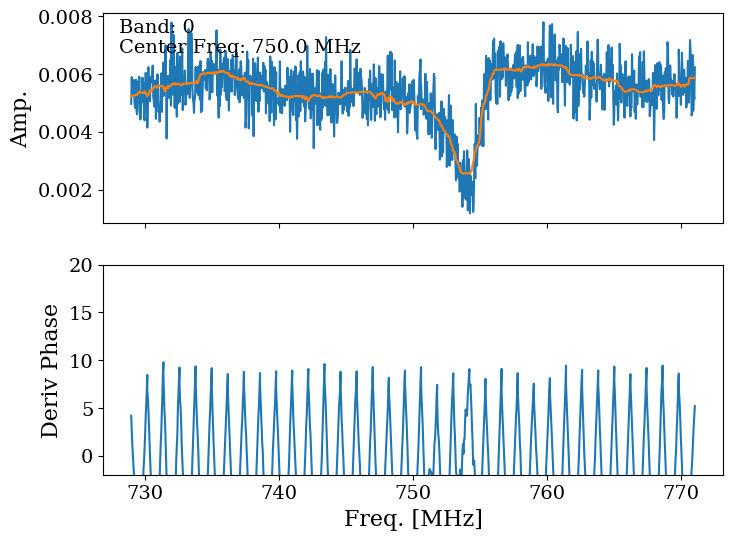

In [165]:
f2, resp2 = freqSweep(S, band=0, start_freq=-20, stop_freq=20, subband=None, tone_power=None, n_avg = 5
                      , makeplot=True)

amp2 = np.abs(resp2)

[ 2026-03-27 06:22:37 ]  No tone_power given. Using value in config file: 12
[ 2026-03-27 06:22:37 ]  Sweeping across frequencies 630.0MHz to 670.0MHz. Averaging 5 traces.
[ 2026-03-27 06:22:38 ]  Working on band 0
[ 2026-03-27 06:22:43 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:22:43 ]  Working on band 0
[ 2026-03-27 06:22:49 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:22:49 ]  Working on band 0
[ 2026-03-27 06:22:54 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:22:54 ]  Working on band 0
[ 2026-03-27 06:23:01 ]  serial find freq complete ; etaScanInProgress = 0
[ 2026-03-27 06:23:01 ]  Working on band 0
[ 2026-03-27 06:23:07 ]  serial find freq complete ; etaScanInProgress = 0


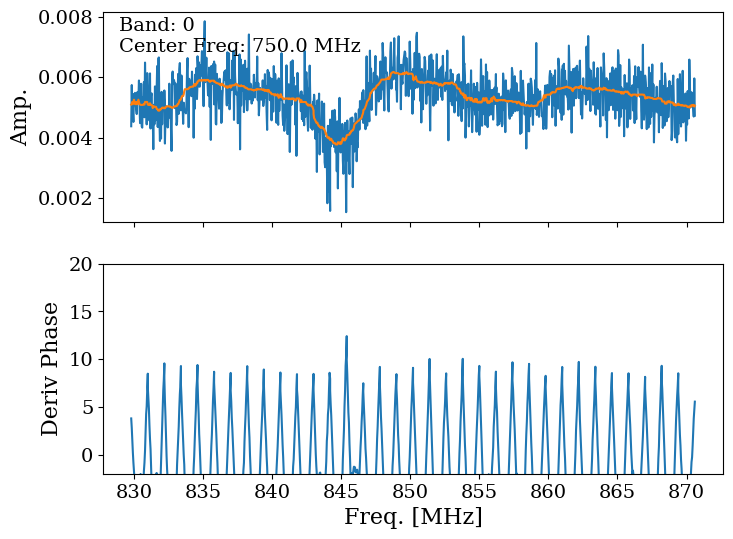

In [172]:
f3, resp3 = freqSweep(S, band=0, start_freq=-120, stop_freq=-80, subband=None, tone_power=None, n_avg = 5
                      , makeplot=True)

amp3 = np.abs(resp3)

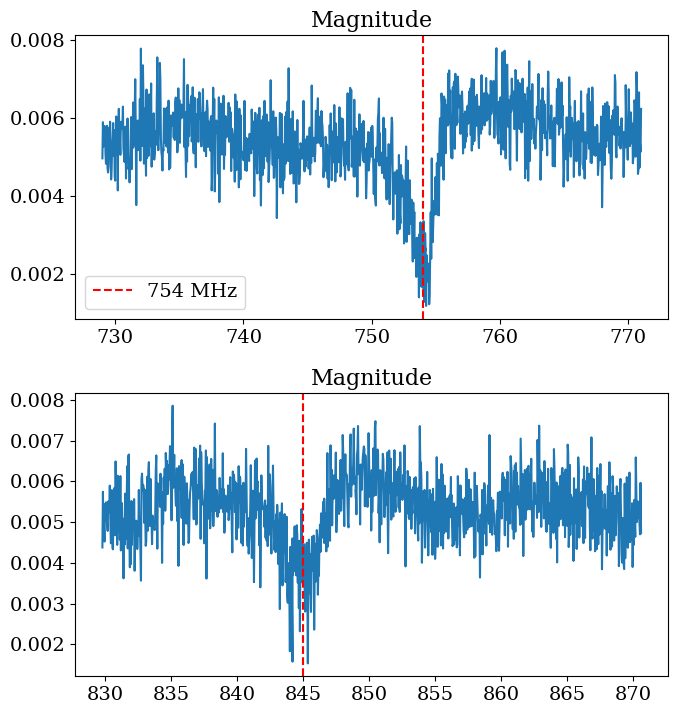

In [174]:
## plot the results
plt.figure(figsize=(7,8))
plt.subplot(2,1,1)
plt.plot(f2, amp2)
#plt.plot(f3, invertedDoubleLorentzian(f3, *popt), 'r-', label = 'fit')
plt.axvline(x=qubit1, color='r', linestyle='--', label=f'{qubit1} MHz')
#plt.axis([8360,8380,-.0001,.0003])
plt.title('Magnitude')
plt.legend()
plt.subplot(2,1,2)
plt.plot(f3, amp3)
plt.axvline(x=qubit2, color='r', linestyle='--', label=f'{qubit2} MHz')
plt.title('Magnitude')
#plt.suptitle(f'qubits, frequency scan with {n_avg} averages')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Use take_debug_data() to read them out individually as a sanity check

In [12]:
S.get_band_center_mhz(0)

6700.0

In [13]:
S.set_band_center_mhz(0, 750)

In [14]:
S.get_band_center_mhz(0)

750.0

In [16]:
S.all_off()
(band, channel1) = S.set_fixed_tone(qubit1, 12)
(band, channel2) = S.set_fixed_tone(qubit2, 12)

[ 2026-04-02 00:21:37 ]  Turning off tones
[ 2026-04-02 00:21:55 ]  Turning off flux ramp
[ 2026-04-02 00:21:55 ]  Turning off all TES biases


In [17]:
print(channel1, channel2)
S.which_on(0)

383 283


array([283, 383])

[ 2026-04-02 00:22:50 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[0]:readoutChannelSelect 383
[ 2026-04-02 00:22:50 ]  Writing to file : /data/smurf_data/20260402/1775089257/outputs/1775089371_single_channel_b0ch383.dat
[ 2026-04-02 00:22:50 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 33554432
[ 2026-04-02 00:22:50 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0
[ 2026-04-02 00:22:50 ]  Data acquisition in progress...
[ 2026-04-02 00:22:51 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:TriggerDaq 1
[ 2026-04-02 00:23:07 ]  Done taking data


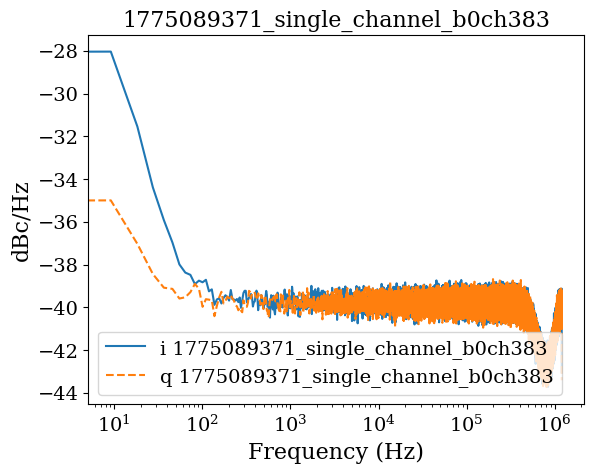

<Figure size 640x480 with 0 Axes>

In [18]:
iq1, sync, filename = takeDebugData(S, band=band, channel=channel1, nsamp=2**25, 
                                   plot=True, show_plot=True, channel_mode=2)

In [ ]:
iq2, sync, filename = takeDebugData(S, band=band, channel=channel2, nsamp=2**25, 
                                   plot=True, show_plot=True, channel_mode=2)

[ 2026-04-02 00:17:48 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:SysgenCryo:Base[0]:readoutChannelSelect 283
[ 2026-04-02 00:17:48 ]  Writing to file : /data/smurf_data/20260325/1774476213/outputs/1775089069_single_channel_b0ch283.dat
[ 2026-04-02 00:17:48 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 33554432
[ 2026-04-02 00:17:48 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0
[ 2026-04-02 00:17:48 ]  Data acquisition in progress...
[ 2026-04-02 00:17:48 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:TriggerDaq 1
[ 2026-04-02 00:18:05 ]  Done taking data


### use butterworth filter at 500 Hz to smooth time domain signals, plot the results

S.get_channel_frequency_mhz(band)=2400000.0


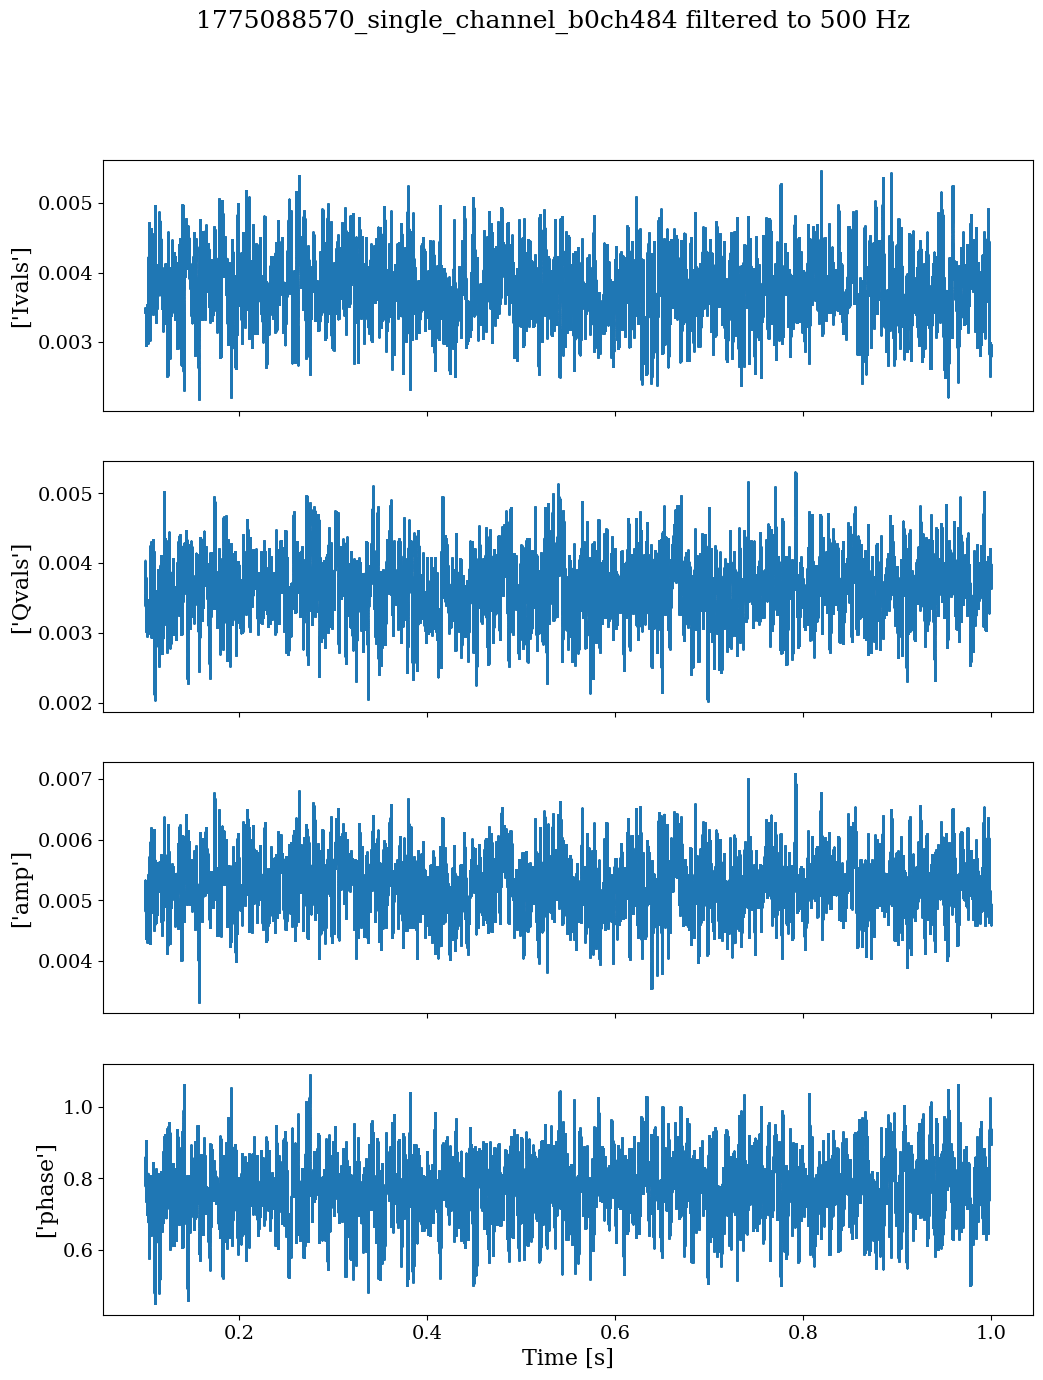

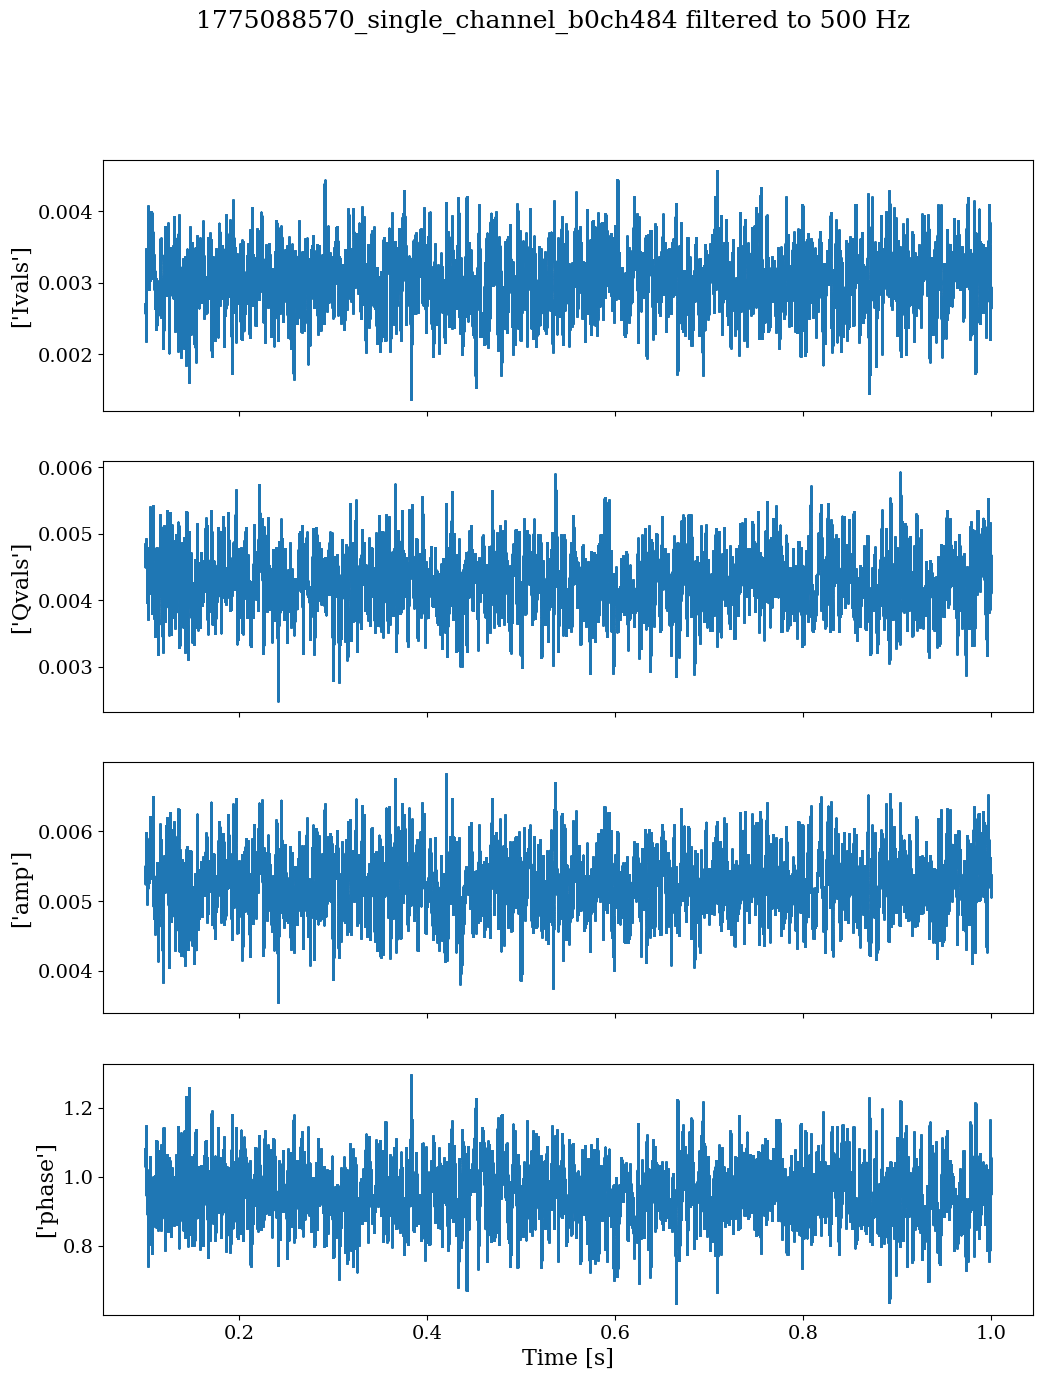

In [253]:
fs = S.get_channel_frequency_mhz(band) * 1.0E6
print(f'S.get_channel_frequency_mhz(band)={fs}')

cutoff_hz = 500
order = 2

iq_list = [iq1, iq2]
for iq in iq_list:
    butter_ivals = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(iq), fs=fs)
    butter_qvals = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(iq), fs=fs)

    start_plot_time_s = 0.1
    stop_plot_time_s = 1
    
    ## Find indices that best match times
    times = np.arange(len(iq)) / fs
    start_plot_idx = np.argmin(np.abs(times - start_plot_time_s))
    stop_plot_idx = np.argmin(np.abs(times - stop_plot_time_s))
    
    fig, ax = plt.subplots(4,1, figsize=(12,15), sharex=True)
    ax[0].plot(times[start_plot_idx:stop_plot_idx], butter_ivals[start_plot_idx:stop_plot_idx], '.',label='I', markersize=0.4)
    ax[0].set_ylabel(['Ivals'])
    
    ax[1].plot(times[start_plot_idx:stop_plot_idx], butter_qvals[start_plot_idx:stop_plot_idx],'.', label='Q', markersize=0.4)
    ax[1].set_ylabel(['Qvals'])
    
    ax[2].plot(times[start_plot_idx:stop_plot_idx], np.abs(butter_ivals+1j*butter_qvals)[start_plot_idx:stop_plot_idx], '.', label='amp', markersize=0.4)
    ax[2].set_ylabel(['amp'])
    
    ax[3].plot(times[start_plot_idx:stop_plot_idx], np.unwrap(np.angle(butter_ivals+1j*butter_qvals)[start_plot_idx:stop_plot_idx]), '.', label='phase', markersize=0.4)
    ax[3].set_ylabel(['phase'])
    ax[3].set_xlabel('Time [s]')
    
    fig.suptitle(f'{filename} filtered to {cutoff_hz} Hz')
    
    plt.show()

# Playing around with streaming

In [19]:
S.get_sample_frequency() #in Hz

1875.0

In [20]:
S.set_lms_gain(band,7)

In [21]:
from pysmurf.client.util.SmurfFileReader import SmurfStreamReader
S._caput(f'{S.app_core}baySelStream', 0, write_log=True)
S._caput(f'{S.app_core}modeStream', 1,write_log=True)
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream',write_log=True)}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream',write_log=True)}")

[ 2026-04-02 00:23:32 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream 0
[ 2026-04-02 00:23:32 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream 1
[ 2026-04-02 00:23:32 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream
[ 2026-04-02 00:23:32 ]  0
baySelStream: 0
[ 2026-04-02 00:23:32 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream
[ 2026-04-02 00:23:32 ]  1
modeStream: 1


In [22]:
S.get_band_center_mhz(0)

750.0

In [23]:
S.set_band_center_mhz(0, 750)

In [24]:
S.get_band_center_mhz(0)

750.0

In [175]:
S.all_off()
S.set_fixed_tone(qubit1, 12)
S.set_fixed_tone(qubit2, 12)

[ 2026-03-27 06:23:33 ]  Turning off tones
[ 2026-03-27 06:23:49 ]  Turning off flux ramp
[ 2026-03-27 06:23:49 ]  Turning off all TES biases


(0, 484)

Let's see what's on

In [25]:
S.which_on(0)

array([283, 383])

[ 2026-04-02 00:23:46 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-04-02 00:23:46 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0


/usr/local/src/pysmurf/python/pysmurf/client/util/smurf_util.py:1770: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_fn)


[ 2026-04-02 00:23:48 ]  ADC plot saved to /data/smurf_data/20260402/1775089257/plots/1775089426_adc0.png
[ 2026-04-02 00:23:48 ]  Saving raw adc data to /data/smurf_data/20260402/1775089257/outputs/1775089426_adc0


/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


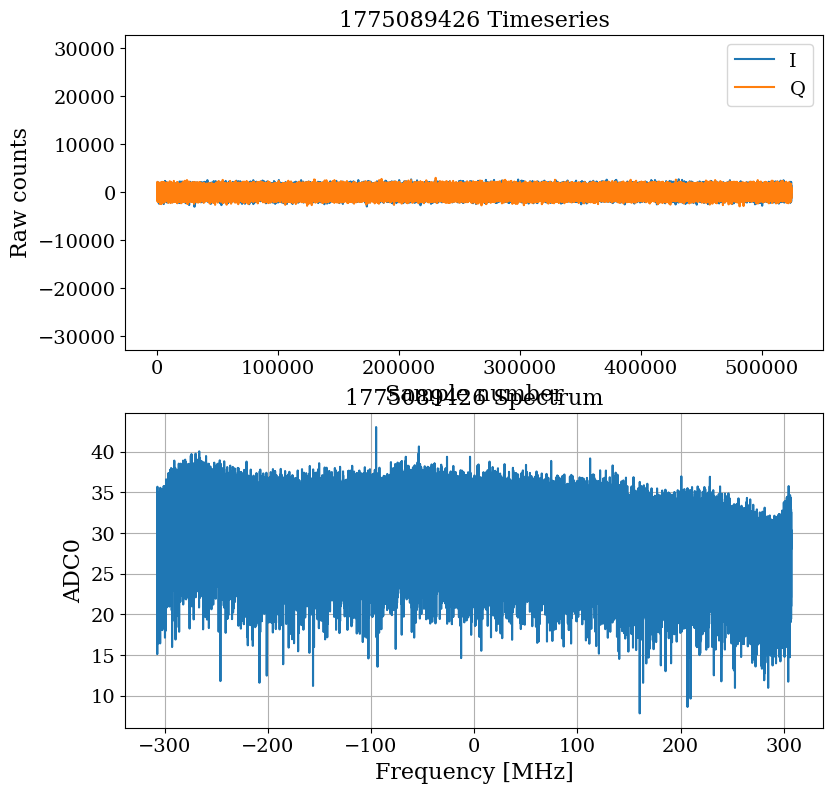

In [26]:
adc=S.read_adc_data(band,make_plot=True,show_plot=True)

In [111]:
S.get_band_center_mhz(band=0)

750.0

It appears that setting modeStream: 1 resets the band center to the default of 750 MHz
update 02/19/26: after some updates to pysmurf, this is no longer the case.

In [27]:
S.stream_data_off()
S.flux_ramp_setup(37.5,0)

[ 2026-04-02 00:24:30 ]  caput smurf_server_s3:AMCc:SmurfProcessor:FileWriter:Close 1
[ 2026-04-02 00:24:30 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:enableStreaming 0
[ 2026-04-02 00:24:30 ]  Waiting 0.15 seconds after...
[ 2026-04-02 00:24:30 ]  Done waiting.
[ 2026-04-02 00:24:30 ]  Percent full scale = 0.000%


In [28]:
S.set_filter_disable(False)
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

S.get_sample_frequency()=37500.0
S.get_downsample_factor()=1
S.get_filter_disable()=0


In [29]:
import scipy.signal as signal
# I think this configures for a 12 kHz roll-off.
b, a = signal.butter(4, 12.0 / 37.5)
S.set_filter_a(a)
S.set_filter_b(b)

Check frame loss:

In [30]:
cnt0=S.get_frame_count()
losscnt0=S.get_frame_loss_cnt()

# Here IQ_mode tells the data-taking and read-back that we're taking data in the nonstandard I/Q mode.
data_file=S.take_stream_data(10,IQ_mode=True)

cnt1=S.get_frame_count()
losscnt1=S.get_frame_loss_cnt()

[ 2026-04-02 00:24:39 ]  Starting to take data.
[ 2026-04-02 00:24:39 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-04-02 00:24:39 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-04-02 00:24:39 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-04-02 00:24:39 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-04-02 00:24:39 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-04-02 00:24:39 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-04-02 00:24:39 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-04-02 00:24:39 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-04-02 00:24:46 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-04-02 00:24:46 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-04-02 00:24:46 ]  Writing to file : /data/smurf_data/20260402/1775089257/outputs/1775089487.dat
[ 2026-04-02 00:24:46 ]  /data/smurf_data/20260402/1775089257/outputs/1775089487_mask.txt
[ 2026-04-02 00:2

In [31]:
print(f'Number of frames = {cnt1-cnt0}')
print(f'Number of frames lost = {losscnt1-losscnt0}')

Number of frames = 322144
Number of frames lost = 0


In [32]:
print(f'Expected {10./(1./(1.e3*S.get_flux_ramp_freq()))} frames')

Expected 375000.0 frames


Close, but not quite. Shawn says there are some 'counters' that aren't checked at these high rates that we should worry about

In [33]:
filesize_MB = os.path.getsize(data_file)/1024**2
print(f'file size: {filesize_MB} MB')

file size: 42.53139019012451 MB


In [ ]:
t,d,m,h=S.read_stream_data(data_file,return_header=True)

In [186]:
S.get_channel_frequency_mhz(band)

2.4

In [35]:
accum_factor=(1.e6*S.get_channel_frequency_mhz(band))/(S.get_flux_ramp_freq()*1.e3)
bit_factor=2**(12-S.get_lms_gain(band))*2**(7) # this 

print(f'bit_factor = {bit_factor}')
print(f'accum_factor = {accum_factor}')

bit_factor = 4096
accum_factor = 64.0


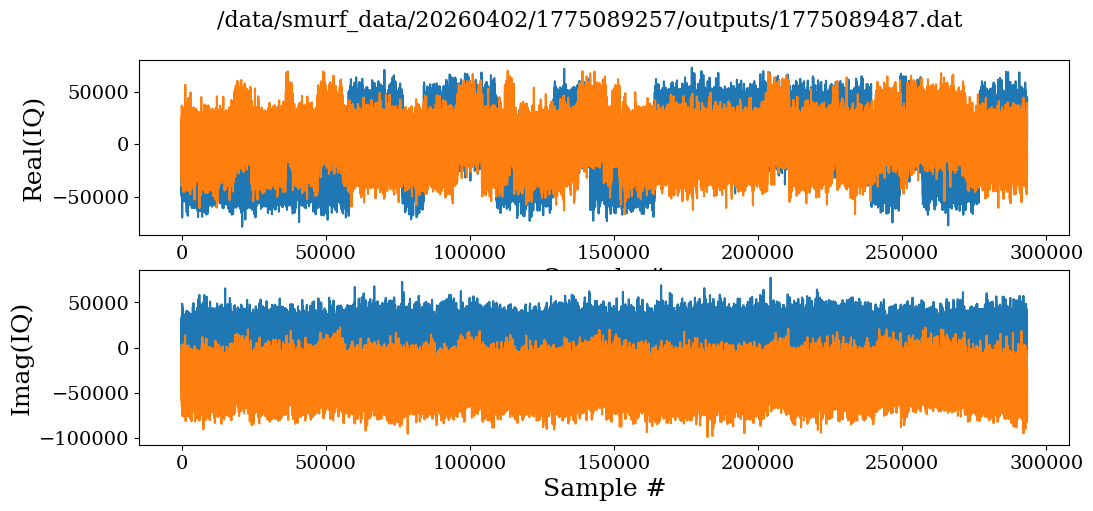

In [36]:
yoffset=1000
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
for ch in range(len(S.which_on(band))):
    ych=bit_factor*d[ch]/accum_factor
    ymax=np.max(ych)
    ymin=np.min(ych)
    yspan=ymax-ymin
    ymedian=np.median(ych)
    ax1.plot(np.real(ych-ymedian) + yoffset*ch)
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Sample #',fontsize=18)
    ax2.plot(np.imag(ych-ymedian) + yoffset*ch)
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Sample #',fontsize=18)
    fig.suptitle(data_file,fontsize=16)
    #ax2.plot(np.real(ych-ymedian) + yoffset*ch)

In [37]:
fs = S.get_channel_frequency_mhz(band) * 1.0E6
fs = S.get_sample_frequency()
print(fs)

37500.0


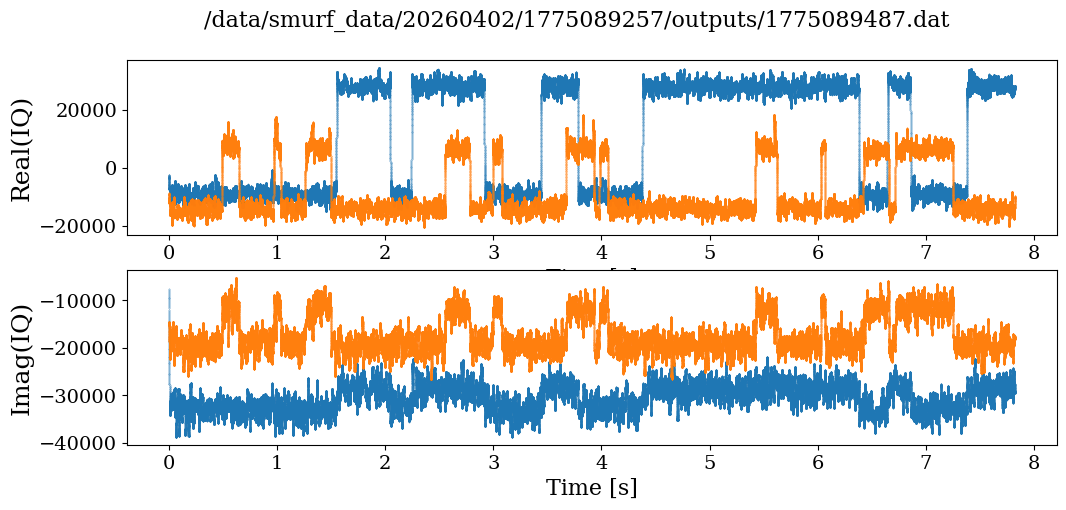

In [39]:
cutoff_hz = 100
order = 2

start_plot_time_s = 0.001
stop_plot_time_s = 10

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
for ch in range(len(S.which_on(band))):
    ych=bit_factor*d[ch]/accum_factor

    ## Find indices that best match times
    times = np.arange(len(ych)) / fs
    start_plot_idx = np.argmin(np.abs(times - start_plot_time_s))
    stop_plot_idx = np.argmin(np.abs(times - stop_plot_time_s))

    butter_ivals = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.real(ych), fs=fs)
    butter_qvals = butterworth_filter(cutoff_hz=cutoff_hz, order=order, data=np.imag(ych), fs=fs)

    ax1.plot(times[start_plot_idx:stop_plot_idx], butter_ivals[start_plot_idx:stop_plot_idx], '.',label='I', markersize=0.4)
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Time [s]')
    ax2.plot(times[start_plot_idx:stop_plot_idx], butter_qvals[start_plot_idx:stop_plot_idx],'.', label='Q', markersize=0.4)
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Time [s]')
    fig.suptitle(data_file,fontsize=16)

In [69]:
print('Pysmurf Client Version:',pysmurf.__version__)
print('Rogue Version:',S._caget(f'{epics_prefix}:AMCc:RogueVersion', as_string=True))
print('Pysmurf Core Version:', S._caget(f'{epics_prefix}:AMCc:SmurfApplication:SmurfVersion', as_string=True))
print('FPGA Git Hash Short:', S.get_fpga_git_hash_short())
print('Config file:', S.config.filename)
print('Cryocard FW Version:', S.C.get_fw_version())

Pysmurf Client Version: 9.0.0+33.g7ecb2867.dirty
Rogue Version: v4.11.11
Pysmurf Core Version: 9.0.0+24.g2b076d38.dirty
FPGA Git Hash Short: 9355e2a
Config file: /usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg
Cryocard FW Version: (0, 0, 0)


In [ ]:
S.read_stream_data??

In [55]:
fname = S.take_stream_data(10, IQ_mode = True)

[ 2026-03-05 23:10:00 ]  Starting to take data.
[ 2026-03-05 23:10:00 ]  Input downsample factor is None. Using value already in pyrogue: 20
[ 2026-03-05 23:10:00 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-03-05 23:10:00 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-03-05 23:10:00 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-03-05 23:10:00 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-03-05 23:10:00 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-03-05 23:10:00 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-03-05 23:10:00 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-03-05 23:10:04 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-03-05 23:10:04 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-03-05 23:10:04 ]  Writing to file : /data/smurf_data/20260305/1772750293/outputs/1772752204.dat
[ 2026-03-05 23:10:04 ]  /data/smurf_data/20260305/1772750293/outputs/1772752204_mask.txt
[ 2026-03-05 23:

In [56]:
print(fname)
filesize_MB = os.path.getsize(fname)/1024**2
print(f'file size: {filesize_MB} MB')

/data/smurf_data/20260305/1772750293/outputs/1772752204.dat
file size: 2.184408187866211 MB


In [ ]:
S.read_stream_data??

In [57]:
t, not_phase, _ = S.read_stream_data(fname, IQ_mode = True)

[ 2026-03-05 23:10:14 ]  Reading /data/smurf_data/20260305/1772750293/outputs/1772752204.dat
Processing data records from /data/smurf_data/20260305/1772750293/outputs/1772752204.dat
[ 2026-03-05 23:10:14 ]  2048 elements loaded
[ 2026-03-05 23:10:14 ]  4096 elements loaded
[ 2026-03-05 23:10:15 ]  6144 elements loaded
[ 2026-03-05 23:10:15 ]  8192 elements loaded
[ 2026-03-05 23:10:15 ]  10240 elements loaded
[ 2026-03-05 23:10:15 ]  12288 elements loaded
[ 2026-03-05 23:10:15 ]  14336 elements loaded
Processed 15022 data records from /data/smurf_data/20260305/1772750293/outputs/1772752204.dat
Processed a total of 15022 data records


In [58]:
print(not_phase.shape)
print(not_phase)
print(np.nonzero(not_phase[0][:416]))
#print(np.nonzero(not_phase[1][:416]))
print(not_phase[0][1])

(2, 15022)
[[-1.-1.j -1.-1.j -1.+0.j ... -1.-1.j  0.-1.j -1.-1.j]
 [ 4.-2.j  4.-2.j  4.-2.j ...  4.-1.j  4.-1.j  4.-1.j]]
(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 1

[272 495]


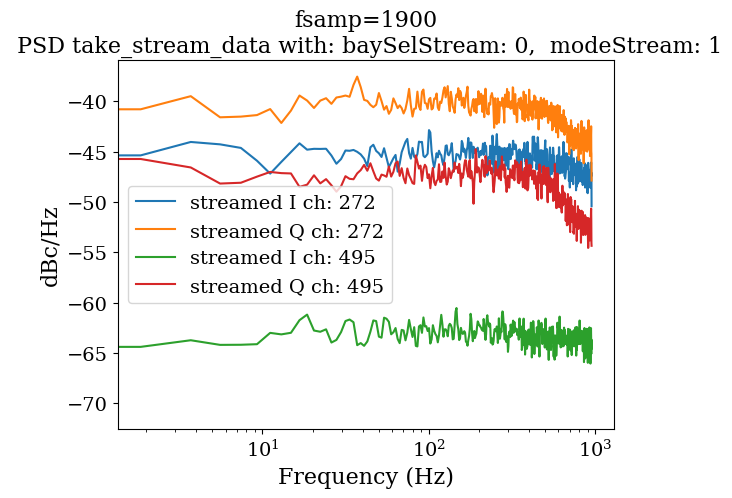

In [59]:
nperseg=2**10
fsamp = 1900
#channels = np.nonzero(not_phase[:416])[0]
channels = S.which_on(0)
print(channels)
for i, row in enumerate(not_phase):
    row1 = row
    I = row1.real
    Q = row1.imag
    ffi,pxxi = welch(I,fs=fsamp,nperseg=nperseg)
    ffq,pxxq = welch(Q,fs=fsamp,nperseg=nperseg)
    # scale to dBc/Hz by the voltage magnitude
    magfac = np.mean(Q)**2 + np.mean(I)**2
    pxxi_dbc = 10. * np.log10(pxxi / magfac)
    pxxq_dbc = 10. * np.log10(pxxq / magfac)
    plt.semilogx(ffi,pxxi_dbc, label=f'streamed I ch: {channels[i]}')
    plt.semilogx(ffq,pxxq_dbc, label=f'streamed Q ch: {channels[i]}')

    
plt.gca().set_aspect('equal')
plt.ylabel('dBc/Hz')
plt.xlabel('Frequency (Hz)')
plt.title( "fsamp=1900\n PSD take_stream_data with: baySelStream: 0,  modeStream: 1")
plt.legend()

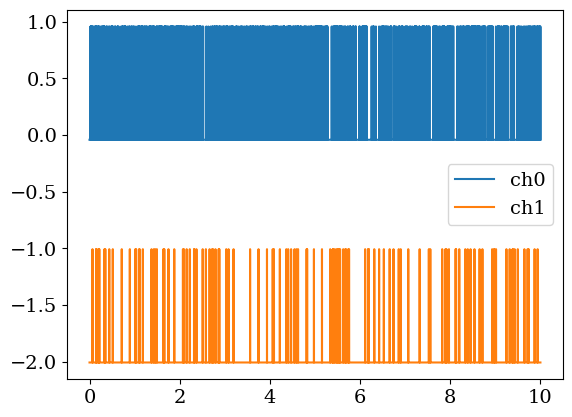

In [61]:
for ch in range(len(not_phase)):
    plt.plot((t-t[0])/1.e9,not_phase[ch]-np.mean(not_phase[ch])-2*ch,label=f'ch{ch}')
plt.legend()
plt.show()

In [62]:
# Sample rate (can't go above 38ish)
S.flux_ramp_setup(38.0,0) # first number in kHz, 2nd number only matters for uMUX

# Configure filter / downsample
S.set_filter_disable(True)
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

[ 2026-02-20 21:18:25 ]  Percent full scale = 0.000%
S.get_sample_frequency()=38000.9896091044
S.get_downsample_factor()=1
S.get_filter_disable()=1


In [64]:
# loss counter tells you if you lost any frames btw rfsoc and pcie card.  
# Very unlikely at these channel counts, but good to check.
loss0 = S.get_frame_loss_cnt()
fname = S.take_stream_data(10,IQ_mode=True) # also dump a short full stream during this - use the `streamingInterface`
loss1 = S.get_frame_loss_cnt()
print(f'Frames lost = {loss1-loss0} should be zero.')

[ 2026-02-20 21:21:01 ]  Starting to take data.
[ 2026-02-20 21:21:01 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-02-20 21:21:01 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-02-20 21:21:01 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-02-20 21:21:01 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-02-20 21:21:01 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-02-20 21:21:01 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-02-20 21:21:01 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-02-20 21:21:01 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-02-20 21:21:05 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-02-20 21:21:05 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-02-20 21:21:05 ]  Writing to file : /data/smurf_data/20260220/1771553874/outputs/1771622465.dat
[ 2026-02-20 21:21:05 ]  /data/smurf_data/20260220/1771553874/outputs/1771622465_mask.txt
[ 2026-02-20 21:2

In [66]:
print(fname)
filesize_MB = os.path.getsize(fname)/1024**2
print(f'file size: {filesize_MB} MB')

/data/smurf_data/20260220/1771553874/outputs/1771622465.dat
file size: 43.35273551940918 MB


In [73]:
S.get_processed_channels(0)

array([  0,   2,   3,   4,   5,   6,   7,   8,  10,  11,  12,  13,  15,
        16,  18,  19,  20,  21,  22,  23,  24,  26,  27,  28,  29,  31,
        32,  34,  35,  36,  37,  38,  39,  40,  42,  43,  44,  45,  47,
        48,  50,  51,  52,  53,  55,  56,  57,  58,  59,  60,  61,  63,
        64,  66,  67,  68,  69,  70,  71,  72,  74,  75,  76,  77,  79,
        80,  82,  83,  84,  85,  87,  88,  89,  90,  91,  92,  93,  95,
        96,  98,  99, 100, 101, 102, 103, 104, 106, 107, 108, 109, 111,
       112, 114, 115, 116, 117, 119, 120, 121, 122, 123, 124, 125, 127,
       128, 130, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 143,
       144, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 159,
       160, 162, 163, 164, 165, 166, 167, 168, 170, 171, 172, 173, 175,
       176, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191,
       192, 194, 195, 196, 197, 198, 199, 200, 202, 203, 204, 205, 207,
       208, 210, 211, 212, 213, 215, 216, 217, 218, 219, 220, 22

In [ ]:
t,d,m = S.read_stream_data(fname,IQ_mode=True)

for ch in range(len(d)):
	plt.plot((t-t[0])/1.e9,d[ch]-np.mean(d[ch])-2*ch,label=f'ch{ch}')
plt.legend()
plt.show()

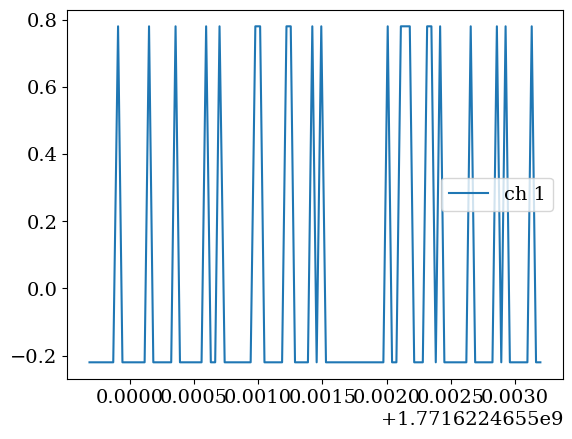

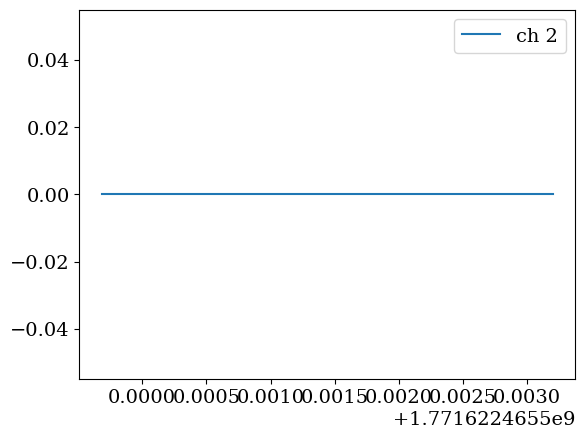

In [72]:
#plot first 100 values
plt.plot((t[0:100])/1.e9, d[0][0:100]-np.mean(d[0][0:100]), label = f'ch 1')
plt.legend()
plt.show()

#plot first 100 values
plt.plot((t[0:100])/1.e9, d[1][0:100]-np.mean(d[1][0:100]), label = f'ch 2')
plt.legend()
plt.show()

# let's move the tone away from the SQUAT

In [ ]:
m1 = -90.3

In [ ]:
S.all_off()
S.log('trying to do a PSD thing')
amp_readout_freq = 595.2+m1-40
my_log = f'Sending fixed tone at {amp_readout_freq} MHz'
print(my_log)
S.log(my_log)

(band,channel)=S.set_fixed_tone(amp_readout_freq,12)

In [ ]:
iq, sync, filename = takeDebugData(S, band=band, channel=channel, nsamp=2**25, 
                                   plot=True, show_plot=True, channel_mode=2)

In [ ]:
fs = S.get_channel_frequency_mhz(band) * 1.0E6

ffamp, pxxa = welch(np.abs(iq),fs=fs, nperseg=2**18)
ffphase, pxxph = welch(np.angle(iq),fs=fs, nperseg=2**18)



timestamp = S.get_timestamp() 
filename = f'{timestamp}_single_channel_b{band}ch{channel:03}'
plt.gca().loglog(ffphase,pxxph, linestyle='--',label=f'phase {filename}')
plt.ylabel('phase psd')
plt.xlabel('Frequency (Hz)')
plt.title(filename)
plt.show()

plt.gca().loglog(ffamp,pxxa,linestyle='-',label=f'amp {filename}')
plt.ylabel('amp psd')
plt.xlabel('Frequency (Hz)')
plt.title(filename)

In [ ]:
curoff_hz = 500
order = 2

fs = S.get_channel_frequency_mhz(band) * 1.0E6

def butterworth_filter(data, fs, cutoff_hz=200, order=1):
    b, a = butter(N=order, Wn=cutoff_hz, btype='low', fs=fs)
    zi = sp.signal.lfilter_zi(b, a)
    filt_data, _ = sp.signal.lfilter(b, a, data, zi=zi*data[0])
    return filt_data

butter_ivals = butterworth_filter(cutoff_hz=curoff_hz, order=order, data=np.real(iq), fs=fs)
butter_qvals = butterworth_filter(cutoff_hz=curoff_hz, order=order, data=np.imag(iq), fs=fs)

In [ ]:
start_plot_time_s = 0.1
stop_plot_time_s = 1

## Find indices that best match times
times = np.arange(len(iq)) / fs
start_plot_idx = np.argmin(np.abs(times - start_plot_time_s))
stop_plot_idx = np.argmin(np.abs(times - stop_plot_time_s))

fig, ax = plt.subplots(4,1, figsize=(12,15), sharex=True)
ax[0].plot(times[start_plot_idx:stop_plot_idx], butter_ivals[start_plot_idx:stop_plot_idx], '.',label='I', markersize=0.4)
ax[0].set_ylabel(['Ivals'])

ax[1].plot(times[start_plot_idx:stop_plot_idx], butter_qvals[start_plot_idx:stop_plot_idx],'.', label='Q', markersize=0.4)
ax[1].set_ylabel(['Qvals'])

ax[2].plot(times[start_plot_idx:stop_plot_idx], np.abs(butter_ivals+1j*butter_qvals)[start_plot_idx:stop_plot_idx], '.', label='amp', markersize=0.4)
ax[2].set_ylabel(['amp'])

ax[3].plot(times[start_plot_idx:stop_plot_idx], np.unwrap(np.angle(butter_ivals+1j*butter_qvals)[start_plot_idx:stop_plot_idx]), '.', label='phase', markersize=0.4)
ax[3].set_ylabel(['phase'])
ax[3].set_xlabel('Time [s]')

fig.suptitle(f'{filename} filtered to {curoff_hz} Hz')

plt.show()

In [74]:
# Setup the library
import pyrogue as pr
import pyrogue.utilities.fileio as fileio
import matplotlib.pyplot as plt
import numpy as np
import math
import os

top_level=f'{os.getcwd()}/..'


def MyFileReader(filePath):

    with fileio.FileReader(files=filePath) as fd:   
        
        # Loop through the file data
        for header,data in fd.records():
    
            if (header.error>0):
                # Look at record header data
                print(f"Processing record. Total={fd.totCount}, Current={fd.currCount}")
                print(f"Record size    = {header.size}")
                print(f"Record channel = {header.channel}")
                print(f"Record flags   = {header.flags:#x}")
                print(f"Record error   = {header.error:#x}")
    
            retVar = np.frombuffer(data, dtype='int16', count=(header.size//2))
            
    return retVar
	
data = MyFileReader( f'{top_level}/data/data_20240816_225633.dat' )
for dataSmpl in data:
    print(dataSmpl)

ModuleNotFoundError: No module named 'pyrogue'

In [75]:
import numpy as np

# Function to convert from two's complement to signed integer
def twos_complement(value, bits):
    if value & (1 << (bits - 1)):
        value -= (1 << bits)
    return value
    
def hex_twos_complement_to_signed_integer(hex_str, bit_width):
    # Convert the hexadecimal string to an integer
    unsigned_value = int(hex_str, 16)
    
    # Compute the maximum value for the given bit width
    max_value = 1 << bit_width
    
    # Convert to signed integer if the number is negative
    if unsigned_value >= (max_value >> 1):
        # Subtract the maximum value to get the negative representation
        signed_value = unsigned_value - max_value
    else:
        signed_value = unsigned_value
    
    return signed_value

real_dec = hex_twos_complement_to_signed_integer('042d5', 18)
imag_dec = hex_twos_complement_to_signed_integer('231c0', 18)
print(real_dec)
print(imag_dec)

# Compute the phase in radians
phase_rad = np.arctan2(imag_dec, real_dec)
print(phase_rad)

pha_dec = hex_twos_complement_to_signed_integer('c5d9', 16)
print(pha_dec/32767*np.pi)

17109
-118336
-1.4272114372167637
-1.4273168075805307
